# 06. Classification Basics

## 📚 Learning Objectives

By completing this notebook, you will:
- Train and evaluate classifiers (e.g. sklearn)
- Interpret confusion matrix and metrics
- Compare models and feature importance

## 🔗 Where this fits

**Builds on:** Course 04 (AIAT 114) — Unit 3 (the full classifier line-up) and Course 05 — Unit 4, lesson 05 — several models, one dataset, one confusion matrix each.

**Used later in:** Course 05 — Unit 4, lesson 07, which replaces accuracy with metrics that survive class imbalance.

---


## 🎯 The case: 492 frauds in 284,807 transactions

The `creditcard_fraud` data this notebook ends on is real: **284,807 card transactions**
made by European cardholders over two days in September 2013, released by the Machine
Learning Group at the **Université Libre de Bruxelles** with **Worldline**, the payment
processor. The features are PCA components because the raw transaction fields are
confidential. **492 of the transactions are fraud — 0.173%.** The full file is 151 MB and is
not in this repository, so what runs below is the **16,000-row stratified sample that is**,
drawn to hold that rate: **28 frauds, 0.175%**.

That rate is the entire lesson. A classifier that answers "legitimate" to every transaction,
with no features and no training, is **99.825% accurate** on the 16,000 rows loaded here. It
would pass most accuracy thresholds a manager would write into a contract. It catches zero
frauds.

**What goes wrong without knowing this.** You are about to measure it: on the same test
split, a real classifier scores **93.13% accuracy — lower than the useless dummy** — while
catching **87.5% of the frauds** (recall 0.8750) at a precision of 0.0208. Two models, two
accuracy figures, and the *worse* accuracy belongs to the only one that works.

Before that, on Titanic, you will compare two classifiers that are close on precision
(0.760 vs 0.766) and far apart on recall (0.551 vs 0.710). Which one is "better" is not a
question the data answers. It is a question about what a mistake costs.


## The Story

**BEFORE**: You know linear regression for continuous predictions, but don't know how to predict categories/classes.

**AFTER**: You'll master classification algorithms (Logistic Regression, Decision Trees) to predict categories instead of continuous values!

**Why this matters**: Classification is essential for real-world problems like spam detection, medical diagnosis, and image recognition!

---

# Unit 4 - Example 6: Classification Basics

## 🔗 Solving the Problem from Example 4

**Remember the dead end from Example 4?**
- We learned linear regression for predicting continuous values
- But we discovered we need to predict categories/classes, not continuous values
- Linear regression doesn't work well for classification problems

**This notebook solves that problem!**
- We'll learn **classification algorithms** (Logistic Regression, Decision Trees, etc.)
- We'll learn how to **predict categories** instead of continuous values
- We'll learn **classification metrics** (accuracy, precision, recall, F1-score)

**This solves the classification problem from Example 4!**

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Features, labels
- **Real data:** `titanic` (the whole 891-row file ships with this repository) for the
  survival classifiers, and `creditcard_fraud` for the imbalance demonstration — the
  284,807-row original is not committed, so the 16,000-row sample is what runs, with its
  28 frauds
- sklearn

**Outputs:** What you'll see when you run the cells

- Classifier
- Metrics
- Confusion matrix
- Plots

---

In [1]:
# Step 1: Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve, roc_auc_score)

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("=" * 70)
print("Example 6: Classification Basics")
print("=" * 70)
print("\n📚 Prerequisites: Example 4 completed, linear regression knowledge")
print("🔗 This is Example 06 in Unit 4 - classification algorithms")
print("🎯 Goal: Master classification with logistic regression and decision trees")

Example 6: Classification Basics

📚 Prerequisites: Example 4 completed, linear regression knowledge
🔗 This is Example 06 in Unit 4 - classification algorithms
🎯 Goal: Master classification with logistic regression and decision trees


1. CREATE CLASSIFICATION DATA


In [2]:
# WHAT: Load the real Titanic manifest and build the feature table both classifiers will use.
# WHY: A genuinely hard, genuinely noisy problem is the fair playground for comparing classifiers -
#      survival was NOT a clean function of the six recorded columns, and the scores will show it.

print("\n1. Loading Real Classification Data")
print("-" * 70)

# --- Data setup. Works from any folder, and on Google Colab. -------------------------
# WHAT: find the repository root and put it on sys.path, then import the shared loader.
# WHY:  a hard-coded '../../../Course 04/datasets/raw/titanic.csv' only resolves when the
#       kernel's working directory happens to be this notebook's folder. This does not care.
import sys, pathlib

_here = pathlib.Path.cwd().resolve()
_root = next((p for p in [_here, *_here.parents] if (p / "tools" / "data.py").exists()), None)
if _root is None:                     # Google Colab, or a stray copy of the notebook
    import urllib.request
    pathlib.Path("tools").mkdir(exist_ok=True)
    try:
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/A-Alwabel/"
            "AI-Diploma-Program/main/tools/data.py", "tools/data.py")
    except Exception as _e:
        raise RuntimeError(
            "Could not find the AI Diploma repository from this folder, and could not "
            "download the data loader either. Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet "
            f"and re-run this cell. (underlying error: {_e})") from None
    _root = pathlib.Path.cwd()
sys.path.insert(0, str(_root))

from tools.data import load
# -------------------------------------------------------------------------------------
titanic = load("titanic")

df = titanic[['Age', 'Fare', 'SibSp', 'Parch', 'Pclass', 'Sex', 'Survived']].copy()
n_missing_age = df['Age'].isna().sum()
df['Age'] = df['Age'].fillna(df['Age'].median())      # 177 real gaps
df['is_female'] = (df['Sex'] == 'female').astype(int)
df = df.drop(columns=['Sex']).rename(columns={'Survived': 'target'})

FEATURES = ['Age', 'Fare', 'SibSp', 'Parch', 'Pclass', 'is_female']

print(f"Data shape: {df.shape}")
print(f"Missing ages filled with the median: {n_missing_age} of {len(df)}")
print(f"Target distribution:\n{df['target'].value_counts().to_string()}")
print(f"Positive class rate: {df['target'].mean():.1%}")
print("\nFirst rows:")
print(df.head().to_string())


1. Loading Real Classification Data
----------------------------------------------------------------------
titanic: full file, 891 rows.
Data shape: (891, 7)
Missing ages filled with the median: 177 of 891
Target distribution:
target
0    549
1    342
Positive class rate: 38.4%

First rows:
    Age     Fare  SibSp  Parch  Pclass  target  is_female
0  22.0   7.2500      1      0       3       0          0
1  38.0  71.2833      1      0       1       1          1
2  26.0   7.9250      0      0       3       1          1
3  35.0  53.1000      1      0       1       1          1
4  35.0   8.0500      0      0       3       0          0


2. LOGISTIC REGRESSION


In [3]:
# WHAT: Split, scale, and fit logistic regression; store test predictions and probabilities.
# WHY: Scaling is fit on the training set only - fitting it on all data would leak test information into training.

print("\n\n2. Logistic Regression")
print("-" * 70)
X_data = df[FEATURES]
y_data = df['target']
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.2, random_state=42, stratify=y_data)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
logistic_model = LogisticRegression(random_state=42, max_iter=1000)
logistic_model.fit(X_train_scaled, y_train)
y_test_pred_lr = logistic_model.predict(X_test_scaled)
y_test_proba_lr = logistic_model.predict_proba(X_test_scaled)[:, 1]
accuracy_lr = accuracy_score(y_test, y_test_pred_lr)
baseline = max(y_test.mean(), 1 - y_test.mean())

print(f"\nLogistic Regression Accuracy: {accuracy_lr:.4f}")
print(f"Majority-class baseline:      {baseline:.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred_lr):.4f} | "
      f"Recall: {recall_score(y_test, y_test_pred_lr):.4f} | "
      f"F1: {f1_score(y_test, y_test_pred_lr):.4f}")



2. Logistic Regression
----------------------------------------------------------------------

Logistic Regression Accuracy: 0.8045
Majority-class baseline:      0.6145
Precision: 0.7656 | Recall: 0.7101 | F1: 0.7368


3. DECISION TREE


In [4]:
# WHAT: Fit a depth-5 decision tree and print its feature importances.
# WHY: Trees learn non-linear boundaries and explain themselves - importances say which features drove the splits.

print("\n\n3. Decision Tree")
print("-" * 70)
tree_model = DecisionTreeClassifier(random_state=42, max_depth=5)
tree_model.fit(X_train, y_train)     # trees do not need scaling
y_test_pred_dt = tree_model.predict(X_test)
y_test_proba_dt = tree_model.predict_proba(X_test)[:, 1]
accuracy_dt = accuracy_score(y_test, y_test_pred_dt)
print(f"\nDecision Tree Accuracy: {accuracy_dt:.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred_dt):.4f} | "
      f"Recall: {recall_score(y_test, y_test_pred_dt):.4f} | "
      f"F1: {f1_score(y_test, y_test_pred_dt):.4f}")

# Feature importance - which feature drives the tree's decisions?
print("\nFeature importance (decision tree):")
for name, imp in sorted(zip(FEATURES, tree_model.feature_importances_),
                        key=lambda t: -t[1]):
    print(f"  {name:10s}: {imp:.3f}")
print("(importances sum to 1 - higher = more influence on the splits)")
print("\n💡 The tree puts most of its weight on sex - the same variable the")
print("   logistic model gave the largest coefficient. Two very different")
print("   algorithms agreeing is evidence the pattern is in the data, not the model.")



3. Decision Tree
----------------------------------------------------------------------

Decision Tree Accuracy: 0.7598
Precision: 0.7600 | Recall: 0.5507 | F1: 0.6387

Feature importance (decision tree):
  is_female : 0.534
  Pclass    : 0.182
  Fare      : 0.137
  Age       : 0.127
  SibSp     : 0.011
  Parch     : 0.009
(importances sum to 1 - higher = more influence on the splits)

💡 The tree puts most of its weight on sex - the same variable the
   logistic model gave the largest coefficient. Two very different
   algorithms agreeing is evidence the pattern is in the data, not the model.


4. CONFUSION MATRICES




4. Confusion Matrices
----------------------------------------------------------------------
Logistic Regression:
 [[95 15]
 [20 49]]
Decision Tree:
 [[98 12]
 [31 38]]


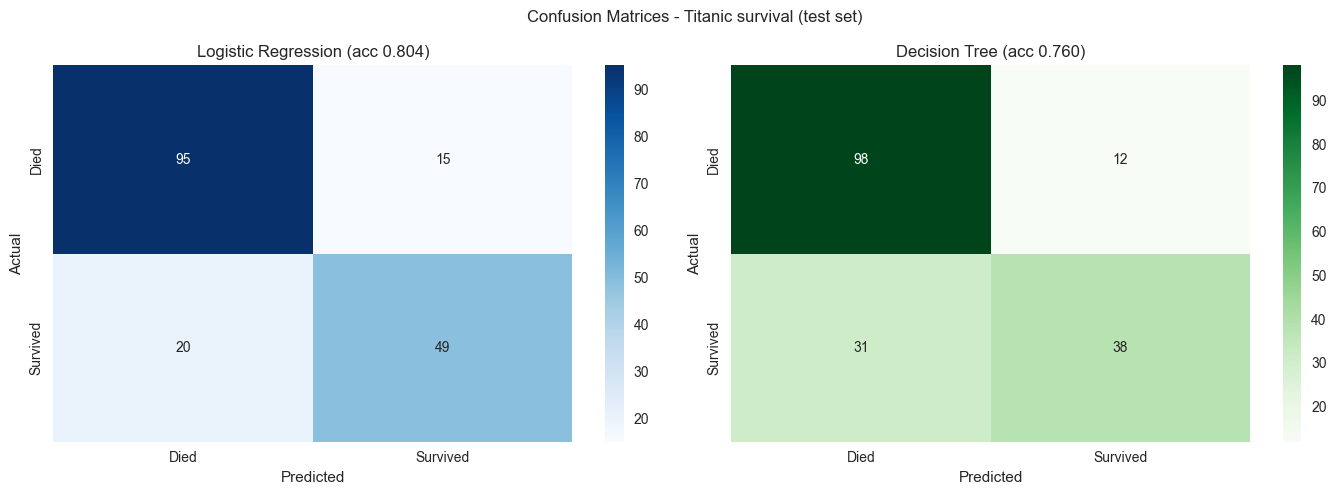

✓ Confusion matrices drawn and saved

False negatives (survivors the model wrote off): logistic 20, tree 31
False positives (deaths predicted as survivals): logistic 15, tree 12


In [5]:
# WHAT: Draw side-by-side confusion matrices for the two models.
# WHY: Reading raw counts of each error type is the honest way to compare classifiers on the same test set.

print("\n\n4. Confusion Matrices")
print("-" * 70)
cm_lr = confusion_matrix(y_test, y_test_pred_lr)
cm_dt = confusion_matrix(y_test, y_test_pred_dt)
print("Logistic Regression:\n", cm_lr)
print("Decision Tree:\n", cm_dt)
labels = ['Died', 'Survived']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Confusion Matrices - Titanic survival (test set)')
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=labels, yticklabels=labels)
axes[0].set_title(f'Logistic Regression (acc {accuracy_lr:.3f})')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=labels, yticklabels=labels)
axes[1].set_title(f'Decision Tree (acc {accuracy_dt:.3f})')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
plt.tight_layout()
plt.savefig('11_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()          # show it in the notebook too - a figure nobody sees teaches nothing
print("✓ Confusion matrices drawn and saved")
print(f"\nFalse negatives (survivors the model wrote off): "
      f"logistic {cm_lr[1, 0]}, tree {cm_dt[1, 0]}")
print(f"False positives (deaths predicted as survivals): "
      f"logistic {cm_lr[0, 1]}, tree {cm_dt[0, 1]}")

**Read the figure.** Two heat maps of the same 179 held-out passengers; rows are what
actually happened, columns are what the model said, and every cell is a count of real people.
The diagonal (top-left, bottom-right) is correct; the off-diagonal is where each model is
wrong, and the two models are wrong in *different* directions. Compare the bottom-left cell —
survivors the model wrote off: the logistic model has **20**, the tree has **31**. Now the
top-right cell — deaths predicted as survivals: logistic **15**, tree **12**. The tree is more
cautious about saying "survived", which buys it three fewer false alarms and costs it eleven
more missed survivors. Their overall accuracies are close; what the two grids show is that
"close on accuracy" can still mean two very different machines.

5. ROC CURVES




5. ROC Curves
----------------------------------------------------------------------


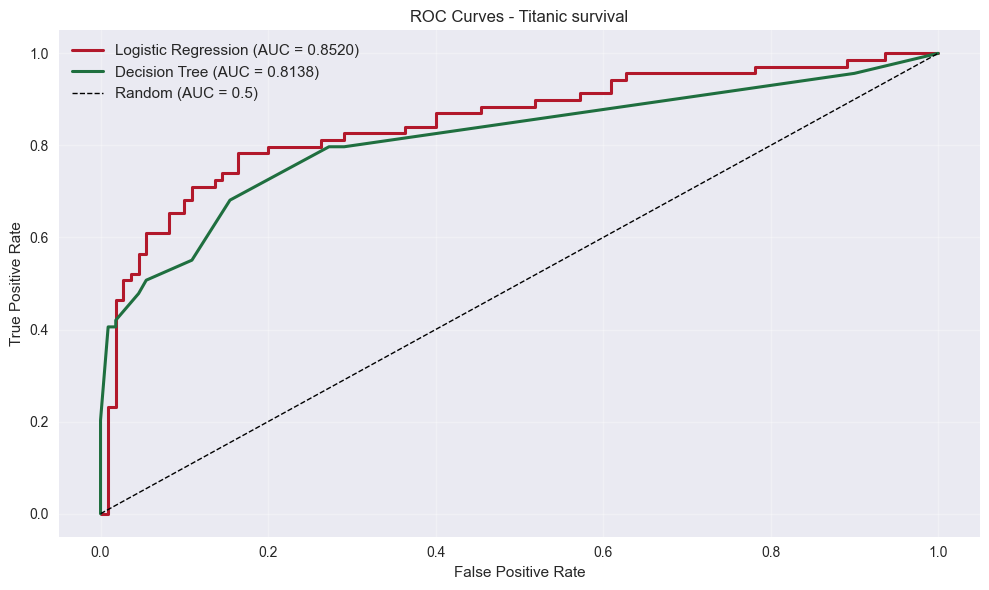

✓ ROC curves drawn and saved
AUC - Logistic Regression: 0.8520 | Decision Tree: 0.8138
💡 AUC is threshold-free: it asks 'if I pick one survivor and one victim at
   random, how often does the model score the survivor higher?'


In [6]:
# WHAT: Plot ROC curves and compute AUC for both models.
# WHY: ROC shows the whole threshold trade-off; AUC condenses it into one comparable number.

print("\n\n5. ROC Curves")
print("-" * 70)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_test_proba_lr)
auc_lr = roc_auc_score(y_test, y_test_proba_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_test_proba_dt)
auc_dt = roc_auc_score(y_test, y_test_proba_dt)
plt.figure(figsize=(10, 6))
# Fix the colours explicitly - the surrounding text names them, so they must not drift.
plt.plot(fpr_lr, tpr_lr, linewidth=2.2, color='#b2182b',
         label=f'Logistic Regression (AUC = {auc_lr:.4f})')
plt.plot(fpr_dt, tpr_dt, linewidth=2.2, color='#1f6f3f',
         label=f'Decision Tree (AUC = {auc_dt:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Titanic survival')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('11_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()          # show it in the notebook too
print(f"✓ ROC curves drawn and saved")
print(f"AUC - Logistic Regression: {auc_lr:.4f} | Decision Tree: {auc_dt:.4f}")
print("💡 AUC is threshold-free: it asks 'if I pick one survivor and one victim at")
print("   random, how often does the model score the survivor higher?'")

**Read the figure.** Both curves start at the bottom-left and climb to the top-right, and the
black dashed diagonal is a coin flip. Every point on a curve is one threshold: slide along it
and you trade false alarms (x-axis) for catches (y-axis). The **dark-red logistic curve sits
above the green decision-tree curve** over almost the whole range — that, and only that, is
what a higher AUC (0.852 against 0.814) means. Look also at their shapes: the logistic curve is
a fine staircase of many small steps, while the tree's is a handful of long straight segments.
A depth-5 tree can only output one probability per leaf, so it has only a few distinct
thresholds to offer, and the straight runs are the gaps between them. Neither curve gets near
the top-left corner: neither model is close to perfect on this problem.

## 💬 Discuss

Two confusion matrices on the same 179 held-out passengers — logistic `[[95, 15], [20, 49]]`
and tree `[[98, 12], [31, 38]]` — and AUCs of **0.852** against **0.814**.

1. The tree makes **fewer false positives (12 vs 15)** and **many more false negatives (31
   vs 20)**. Describe a real application of a survival-type model where you would prefer
   the tree, and one where preferring the tree would be indefensible. Be concrete about who
   is harmed.
2. Both models were told to use a 0.5 threshold. Neither was told what an error costs.
   Where in this notebook's code would you encode "a missed survivor is three times worse
   than a false alarm", and what would happen to accuracy when you did?
3. AUC says logistic is better (0.852 vs 0.814) and it is threshold-free — so it looks like
   the objective answer. Name a situation in which the model with the higher AUC is the
   wrong one to deploy.


6. SUMMARY


In [7]:
# WHAT: Print the summary of the model comparison using the measured numbers.
# WHY: A quick recap of models and metrics before the dead-end demo that follows.

print("\n" + "=" * 70)
print("Summary")
print("=" * 70)
print(f"""
Measured on the real Titanic manifest ({len(df)} passengers, {len(X_test)} held out):

  Majority baseline    accuracy {baseline:.3f}
  Logistic Regression  accuracy {accuracy_lr:.3f}   AUC {auc_lr:.3f}
  Decision Tree (d=5)  accuracy {accuracy_dt:.3f}   AUC {auc_dt:.3f}

Key Concepts Covered:
1. Logistic Regression for classification
2. Decision Tree classifier
3. Confusion matrix analysis (who gets misclassified, and which way)
4. ROC curves and AUC
5. Feature importance from the decision tree

Next Steps: Continue to Example 7 for Model Evaluation
""")


Summary

Measured on the real Titanic manifest (891 passengers, 179 held out):

  Majority baseline    accuracy 0.615
  Logistic Regression  accuracy 0.804   AUC 0.852
  Decision Tree (d=5)  accuracy 0.760   AUC 0.814

Key Concepts Covered:
1. Logistic Regression for classification
2. Decision Tree classifier
3. Confusion matrix analysis (who gets misclassified, and which way)
4. ROC curves and AUC
5. Feature importance from the decision tree

Next Steps: Continue to Example 7 for Model Evaluation



## 🚫 When Classification Hits a Dead End

**BEFORE**: We've learned to build classification models.

**AFTER**: We discover we need proper evaluation beyond just accuracy!

**Why this matters**: Accuracy alone can be misleading - we need comprehensive evaluation metrics!

---

### The Problem We've Discovered

We've learned:
- ✅ How to build classification models (Logistic Regression, Decision Trees)
- ✅ How to calculate accuracy
- ✅ How to create confusion matrices and ROC curves

**But we have a problem:**
- ❓ **What if accuracy is misleading (imbalanced classes)?**
- ❓ **What if we need to understand model performance in detail?**
- ❓ **What if we need to compare multiple models properly?**

**The Dead End:**
- We can build models and calculate accuracy
- But accuracy alone doesn't tell the full story
- We need comprehensive evaluation metrics and techniques

---

### Demonstrating the Problem

Let's see why accuracy alone can be misleading:

In [8]:
# WHAT: Show why accuracy misleads, using a REAL extremely imbalanced dataset: credit-card fraud.
# WHY: 0.17% of these transactions are fraud. A model that never predicts fraud scores 99.8%
#      accuracy and catches nothing - the imbalance is real, not a number we chose.

print("\n" + "=" * 70)
print("🚫 DEMONSTRATING THE DEAD END: Accuracy Can Be Misleading")
print("=" * 70)

# Real data: 284,807 European card transactions from September 2013, with the
# 492 confirmed frauds labelled. (Dal Pozzolo et al., ULB / Worldline.)
fraud = load("creditcard_fraud", prefer="sample",
             usecols=['V1', 'V2', 'V3', 'V4', 'V10', 'V14', 'Amount', 'Class'])
y_imbalanced = fraud['Class'].values
n_samples = len(fraud)
n_fraud = int(y_imbalanced.sum())

# Dummy classifier that always predicts class 0 (majority class = legitimate)
y_pred_dummy = np.zeros(n_samples)

accuracy_dummy = accuracy_score(y_imbalanced, y_pred_dummy)
print(f"\n📊 Real Imbalanced Dataset - credit-card fraud:")
print(f"   - Total transactions: {n_samples:,}")
print(f"   - Class 0 (legitimate): {n_samples - n_fraud:,} "
      f"({(n_samples - n_fraud)/n_samples*100:.3f}%)")
print(f"   - Class 1 (fraud):      {n_fraud:,} ({n_fraud/n_samples*100:.3f}%)")

print(f"\n⚠️  Dummy Classifier (Always Predicts 'Legitimate'):")
print(f"   - Accuracy: {accuracy_dummy:.4%}")
print(f"   - This looks superb! But the model is useless!")
print(f"   - Recall on fraud: {recall_score(y_imbalanced, y_pred_dummy, zero_division=0):.4f}")
print(f"   - It misses all {n_fraud} frauds - every single one.")

# A real model on the same data, to show the metrics that DO reveal the difference
Xf = fraud.drop(columns=['Class'])
Xf_train, Xf_test, yf_train, yf_test = train_test_split(
    Xf, y_imbalanced, test_size=0.3, random_state=42, stratify=y_imbalanced)
fraud_scaler = StandardScaler().fit(Xf_train)
fraud_model = LogisticRegression(max_iter=1000, class_weight='balanced')
fraud_model.fit(fraud_scaler.transform(Xf_train), yf_train)
yf_pred = fraud_model.predict(fraud_scaler.transform(Xf_test))
yf_proba = fraud_model.predict_proba(fraud_scaler.transform(Xf_test))[:, 1]

print(f"\n✅ A real classifier on the same test split "
      f"({len(yf_test):,} transactions, {int(yf_test.sum())} frauds):")
print(f"   - Accuracy:  {accuracy_score(yf_test, yf_pred):.4%}  "
      f"(LOWER than the useless dummy!)")
print(f"   - Precision: {precision_score(yf_test, yf_pred, zero_division=0):.4f}")
print(f"   - Recall:    {recall_score(yf_test, yf_pred, zero_division=0):.4f}  "
      f"<- it actually catches frauds")
print(f"   - F1:        {f1_score(yf_test, yf_pred, zero_division=0):.4f}")
print(f"   - ROC AUC:   {roc_auc_score(yf_test, yf_proba):.4f}")

print(f"\n💡 The Problem:")
print(f"   - The dummy beats the real model on ACCURACY and is worthless")
print(f"   - Only recall, precision, F1 and AUC expose the difference")
print(f"   - Which metric you optimise IS a business decision: a missed fraud")
print(f"     and a blocked legitimate card do not cost the same")

print(f"\n📋 What We Need for Proper Evaluation:")
print(f"   1. Multiple metrics (precision, recall, F1, AUC)")
print(f"   2. Cross-validation (robust performance estimation)")
print(f"   3. Learning curves (understand model behavior)")
print(f"   4. Model comparison (which model is actually better?)")

print(f"\n➡️  Solution Needed:")
print(f"   - We need comprehensive model evaluation techniques")
print(f"   - We need to understand metrics beyond accuracy")
print(f"   - This leads us to Example 7: Model Evaluation")

print("\n" + "=" * 70)


🚫 DEMONSTRATING THE DEAD END: Accuracy Can Be Misleading
creditcard_fraud: bundled 16,000-row sample of the 284,807-row original (the full file is on this machine but was not used, because prefer='sample') — every number below is for the sample, not the full file. How it was drawn: stratified so the fraud rate stays 0.175% (28 fraud rows) against 0.173% in the full file; V1-V28 and Amount rounded to 6 decimals.

📊 Real Imbalanced Dataset - credit-card fraud:
   - Total transactions: 16,000
   - Class 0 (legitimate): 15,972 (99.825%)
   - Class 1 (fraud):      28 (0.175%)

⚠️  Dummy Classifier (Always Predicts 'Legitimate'):
   - Accuracy: 99.8250%
   - This looks superb! But the model is useless!
   - Recall on fraud: 0.0000
   - It misses all 28 frauds - every single one.

✅ A real classifier on the same test split (4,800 transactions, 8 frauds):
   - Accuracy:  93.1250%  (LOWER than the useless dummy!)
   - Precision: 0.0208
   - Recall:    0.8750  <- it actually catches frauds
   -

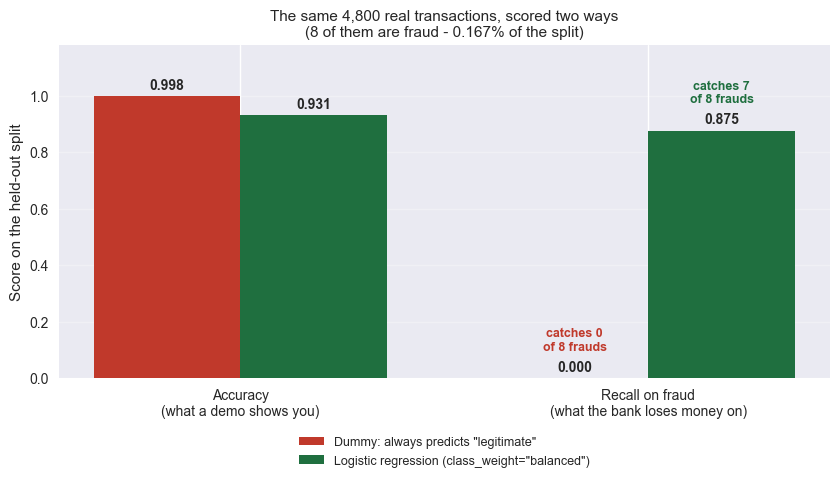

Accuracy: dummy 0.9983 vs real model 0.9313 -> the DUMMY wins by 0.0671
Recall:   dummy 0.0000 vs real model 0.8750 -> the dummy catches nothing at all


In [9]:
# WHAT: Put the useless dummy and the real classifier side by side on TWO metrics.
# WHY: The paragraph above says the dummy "wins" on accuracy and is worthless. On one axis,
#      with accuracy and recall next to each other, that sentence becomes a picture.
import matplotlib.pyplot as plt

dummy_acc = accuracy_score(yf_test, np.zeros(len(yf_test)))
dummy_rec = recall_score(yf_test, np.zeros(len(yf_test)), zero_division=0)
real_acc = accuracy_score(yf_test, yf_pred)
real_rec = recall_score(yf_test, yf_pred, zero_division=0)
n_fraud_test = int(yf_test.sum())

fig, ax = plt.subplots(figsize=(8.5, 5))
groups = ['Accuracy\n(what a demo shows you)', 'Recall on fraud\n(what the bank loses money on)']
x = np.arange(len(groups))
w = 0.36
b1 = ax.bar(x - w / 2, [dummy_acc, dummy_rec], w, color='#c0392b',
            label='Dummy: always predicts "legitimate"')
b2 = ax.bar(x + w / 2, [real_acc, real_rec], w, color='#1f6f3f',
            label='Logistic regression (class_weight="balanced")')
for bars, vals in ((b1, [dummy_acc, dummy_rec]), (b2, [real_acc, real_rec])):
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.015, f"{v:.3f}",
                ha='center', va='bottom', fontsize=10, weight='bold')
# Spell out what recall 0.000 means in people, not decimals.
ax.text(1 - w / 2, 0.10, f"catches 0\nof {n_fraud_test} frauds", ha='center',
        fontsize=9, color='#c0392b', weight='bold')
ax.text(1 + w / 2, real_rec + 0.10,
        f"catches {int(round(real_rec * n_fraud_test))}\nof {n_fraud_test} frauds",
        ha='center', fontsize=9, color='#1f6f3f', weight='bold')

ax.set_xticks(x)
ax.set_xticklabels(groups)
ax.set_ylim(0, 1.18)
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_ylabel('Score on the held-out split')
ax.set_title(f'The same {len(yf_test):,} real transactions, scored two ways\n'
             f'({n_fraud_test} of them are fraud - {yf_test.mean():.3%} of the split)',
             fontsize=11)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.14), ncol=1, fontsize=9, frameon=False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Accuracy: dummy {dummy_acc:.4f} vs real model {real_acc:.4f} "
      f"-> the DUMMY wins by {dummy_acc - real_acc:.4f}")
print(f"Recall:   dummy {dummy_rec:.4f} vs real model {real_rec:.4f} "
      f"-> the dummy catches nothing at all")


**Read the figure.** The same held-out transactions, two metrics, two models. On the left
pair the dummy's bar is visibly the *taller* of the two — the classifier that never predicts
fraud scores higher accuracy than the real one, because 99.83% of these transactions are
legitimate and it gets every one of them right. On the right pair there is **no red bar at
all** — the dummy's recall is 0.000, so it has no height to draw; it catches 0 of the 8
frauds in the test split, while the green bar next to it stands at 0.875 and catches 7 of
them. Accuracy cannot tell these two models apart. Recall separates them instantly. This is the whole argument for the next lesson:
choose the metric that matches the cost of the error before you compare anything.

## 💬 Discuss

Read these four numbers together, all measured on the bundled 16,000-row sample: the dummy
scores **99.8250% accuracy with recall 0.0000**; the real classifier scores **93.1250%
accuracy, recall 0.8750, precision 0.0208, AUC 0.9864** on 4,800 test transactions
containing **8** frauds.

1. Precision **0.0208** means roughly **47 legitimate transactions are flagged for every
   real fraud caught**. For a bank, is that a working system or a customer-service disaster?
   Estimate the daily number of false alarms if the bank processes 500,000 transactions a
   day, then answer again.
2. Your manager's contract says the model must be "at least 99% accurate". Using only the
   numbers above, write the two sentences you would send back. What do you propose the
   contract say instead?
3. Recall 0.8750 means **1 of the 8** test frauds got through. Eight is not a number you can
   build a case on: work out what recall would have been if that one extra fraud had been
   caught, and if one more had been missed. Then say what you would need before quoting a
   recall figure to the bank — and note that the 151 MB original would give you 148 test
   frauds instead of 8.


### What We Need Next

**The Solution**: We need comprehensive model evaluation:
- **Multiple metrics**: Precision, recall, F1-score, AUC (not just accuracy)
- **Cross-validation**: Robust performance estimation
- **Learning curves**: Understand model behavior and overfitting
- **Model comparison**: Proper techniques to compare models

**This dead end leads us to Example 7: Model Evaluation**
- Example 7 will teach us comprehensive evaluation techniques
- We'll learn metrics beyond accuracy
- We'll learn validation methods to properly assess models!


## ⚠️ Where this breaks

- **Accuracy is meaningless without the base rate, and this notebook proves it with
  numbers.** 99.827% is the *floor* on the fraud data, not an achievement. Always print the
  majority-class baseline next to any accuracy figure — the Titanic cells do (61.45%).
- **Precision and recall trade against each other, always.** You cannot maximise both; you
  choose a point on the curve. The choice belongs to whoever bears the cost of each error
  type, and it should be written down before training, not discovered afterwards.
- **AUC hides the operating point.** It averages over every threshold, including thresholds
  nobody would ever ship. On extreme imbalance, **average precision (PR-AUC)** is far more
  informative — with 0.173% positives, ROC-AUC looks impressive because the huge negative
  class makes the false-positive rate tiny by construction.
- **Feature importances agree here, which is reassuring and not proof.** Both models put
  most weight on sex, and the notebook is right that agreement is evidence. But both models
  saw the same six columns, so they can agree on the same confounder — Pclass and Fare
  encode one another (Unit 2 lesson 06, r = −0.55).
- **The assumption that must hold: the training distribution is the deployment
  distribution.** Fraud is adversarial — the attacker changes behaviour precisely because
  you deployed a model. A 2013 fraud pattern is a historical artefact, not a rule, and this
  is the one domain where "concept drift" is not an accident but an opponent.
- **The confusion matrix describes 179 passengers.** One reclassified passenger moves
  accuracy by 0.56 points. Differences smaller than that are noise; use cross-validation
  (lesson 07) before declaring a winner.
- **Cheaper alternative:** before tuning a classifier on extreme imbalance, ask whether the
  problem is really classification. Ranking every transaction by risk and sending the top
  0.5% to a human reviewer sidesteps the threshold question entirely and is what payment
  processors actually do.


## 📚 References

1. Breiman, L., Friedman, J. H., Olshen, R. A., & Stone, C. J. (1984). *Classification and Regression Trees*. Wadsworth.
2. Fawcett, T. (2006). *An Introduction to ROC Analysis*. Pattern Recognition Letters, 27(8), 861-874. <https://doi.org/10.1016/j.patrec.2005.10.010>
3. James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to Statistical Learning*, 2nd ed., Ch. 4 (Classification). Springer. <https://www.statlearning.com>
4. Grinsztajn, L., Flöge, K., Key, O., et al. (2025). *TabPFN-2.5: Advancing the State of the Art in Tabular Foundation Models*. arXiv:2511.08667. <https://arxiv.org/abs/2511.08667>
5. Erickson, N., Purucker, L., Tschalzev, A., et al. (2025). *TabArena: A Living Benchmark for Machine Learning on Tabular Data*. arXiv:2506.16791. <https://arxiv.org/abs/2506.16791>
